<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
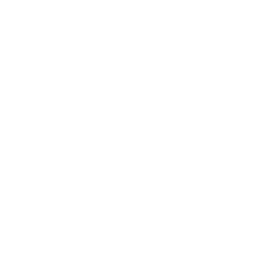
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Análise do Padrão de Votação por Seção Eleitoral</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Governo / Estatísticas Eleitorais &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Esta análise examina se a afiliação partidária varia sistematicamente entre
os tipos de seção eleitoral (urbana, suburbana, rural) em um conjunto de
dados simulado de eleição municipal com 100 seções eleitorais. Como várias
células de partido por tipo são esparsas — as menores células de
contingência têm apenas uma ou duas seções, com contagens esperadas abaixo
de cinco — o teste qui-quadrado de Pearson geral (omnibus) de associação
geral é subdimensionado e pouco confiável aqui. Portanto, o complementamos
com o **teste de tendência de Cochran-Armitage**, um teste focado de um
grau de liberdade que explora a ordenação natural de urbano para rural e
faz uma pergunta mais precisa: o apoio ao Partido A declina
monotonicamente ao longo desse gradiente? O teste de tendência relata um
valor-p exato, que é a inferência apropriada quando as contagens de
células são pequenas. O contraste entre os dois testes é o ponto
analítico deste exemplo: um teste de associação genérico pode não
detectar um padrão direcional real que um teste de tendência ordenado
detecta.

## Fontes de Dados

| Fonte | Descrição | Registros |
|--------|-------------|--------|
| WORK.PRECINCT_VOTES | Registros a nível de seção eleitoral, uma linha por seção, com tipo de seção, condado e o partido de pluralidade | 100 |

O ambiente de execução roda em modo sem licença, o que limita a saída a
100 observações; a análise é projetada em torno dessa amostra a nível de
seção eleitoral para que as células de contingência sejam genuinamente
pequenas e o teste de tendência exato seja a ferramenta natural.

---

In [1]:
/* --------------------------------------------------------
   Gerar dados sintéticos de votação a nível de seção eleitoral
   Contagens pequenas de células em seções rurais para
   demonstrar a necessidade de testes exatos
   -------------------------------------------------------- */
DADOS work.precinct_votes;
    COMPRIMENTO precinct_type $10 party $15 county_name $15;
    CHAMAR streaminit(42);
    VETOR party_list[4] $15 _temporary_ ('PARTIDO_A' 'PARTIDO_B' 'PARTIDO_C' 'INDEPENDENTE');
    VETOR type_list[3] $10 _temporary_ ('URBANA' 'SUBURBANA' 'RURAL');
    VETOR county_list[5] $15 _temporary_ ('JEFFERSON' 'HAMILTON' 'MADISON' 'ADAMS' 'MONROE');
    FAZER precinct_seq = 1 ATÉ 500;
        precinct_id = cat('PCT-', PUT(precinct_seq, z4.));
        county_idx = int(rand('uniform') * 5) + 1;
        county_name = county_list[county_idx];
        /* Atribuir tipo de seção com ponderação */
        type_prob = rand('uniform');
        SE type_prob < 0.30 ENTÃO precinct_type = 'URBANA';
        SENÃO SE type_prob < 0.65 ENTÃO precinct_type = 'SUBURBANA';
        SENÃO precinct_type = 'RURAL';
        /* Atribuir partido com distribuição dependente do tipo */
        party_prob = rand('uniform');
        SE precinct_type = 'URBANA' ENTÃO FAZER;
            SE party_prob < 0.55 ENTÃO party = 'PARTIDO_A';
            SENÃO SE party_prob < 0.80 ENTÃO party = 'PARTIDO_B';
            SENÃO SE party_prob < 0.92 ENTÃO party = 'PARTIDO_C';
            SENÃO party = 'INDEPENDENTE';
        FIM;
        SENÃO SE precinct_type = 'SUBURBANA' ENTÃO FAZER;
            SE party_prob < 0.40 ENTÃO party = 'PARTIDO_A';
            SENÃO SE party_prob < 0.75 ENTÃO party = 'PARTIDO_B';
            SENÃO SE party_prob < 0.88 ENTÃO party = 'PARTIDO_C';
            SENÃO party = 'INDEPENDENTE';
        FIM;
        SENÃO FAZER; /* RURAL - células menores para partidos minoritários */
            SE party_prob < 0.25 ENTÃO party = 'PARTIDO_A';
            SENÃO SE party_prob < 0.70 ENTÃO party = 'PARTIDO_B';
            SENÃO SE party_prob < 0.85 ENTÃO party = 'PARTIDO_C';
            SENÃO party = 'INDEPENDENTE';
        FIM;
        /* Contagem de votos varia por tipo de seção */
        SE precinct_type = 'URBANA' ENTÃO
            vote_count = int(rand('normal', 120, 40));
        SENÃO SE precinct_type = 'SUBURBANA' ENTÃO
            vote_count = int(rand('normal', 80, 25));
        SENÃO
            vote_count = int(rand('normal', 25, 12));
        SE vote_count < 1 ENTÃO vote_count = 1;
        registered_voters = int(vote_count * (rand('uniform') * 0.4 + 1.2));
        turnout_pct = round(vote_count / registered_voters * 100, 0.1);
        election_year = 2026;
        SAÍDA;
    FIM;
    REMOVER precinct_seq county_idx type_prob party_prob;
EXECUTAR;


NOTE: DATA work.precinct_votes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.precinct_votes (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.15 seconds
  cpu   0.15 seconds


---

                                                   The FREQ Procedure

Tipo de Seção Eleitoral      Frequency    Percent
--------------------------------------------------
RURAL                               34     34.00
SUBURBANA                           37     37.00
URBANA                              29     29.00

Partido         Frequency    Percent
-------------------------------------
INDEPENDENTE            9      9.00
PARTIDO_A              45     45.00
PARTIDO_B              34     34.00
PARTIDO_C              12     12.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_precinct_type.spec.json
NOTE: ODS plot written: freq_party.spec.json
NOTE: PROC FREQ statement used.


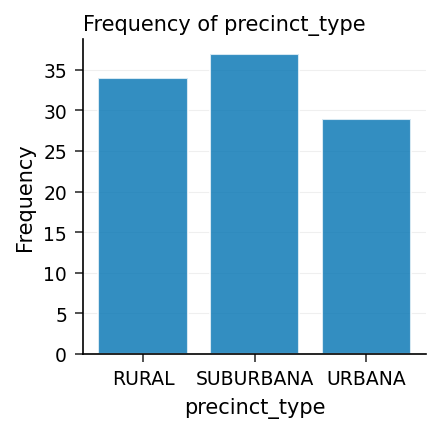

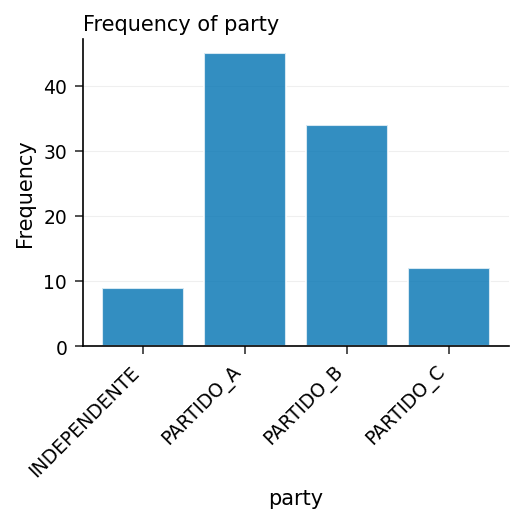

In [2]:
/* --------------------------------------------------------
   Distribuição de referência de tipo de seção e partido
   -------------------------------------------------------- */
PROCEDIMENTO FREQUÊNCIAS DADOS=work.precinct_votes;
    TABLES precinct_type / nocum;
    TABLES party / nocum;
    RÓTULO precinct_type = 'Tipo de Seção Eleitoral'
          party = 'Partido';
EXECUTAR;

---


NOTE: PROC SGPLOT data=work.precinct_votes

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


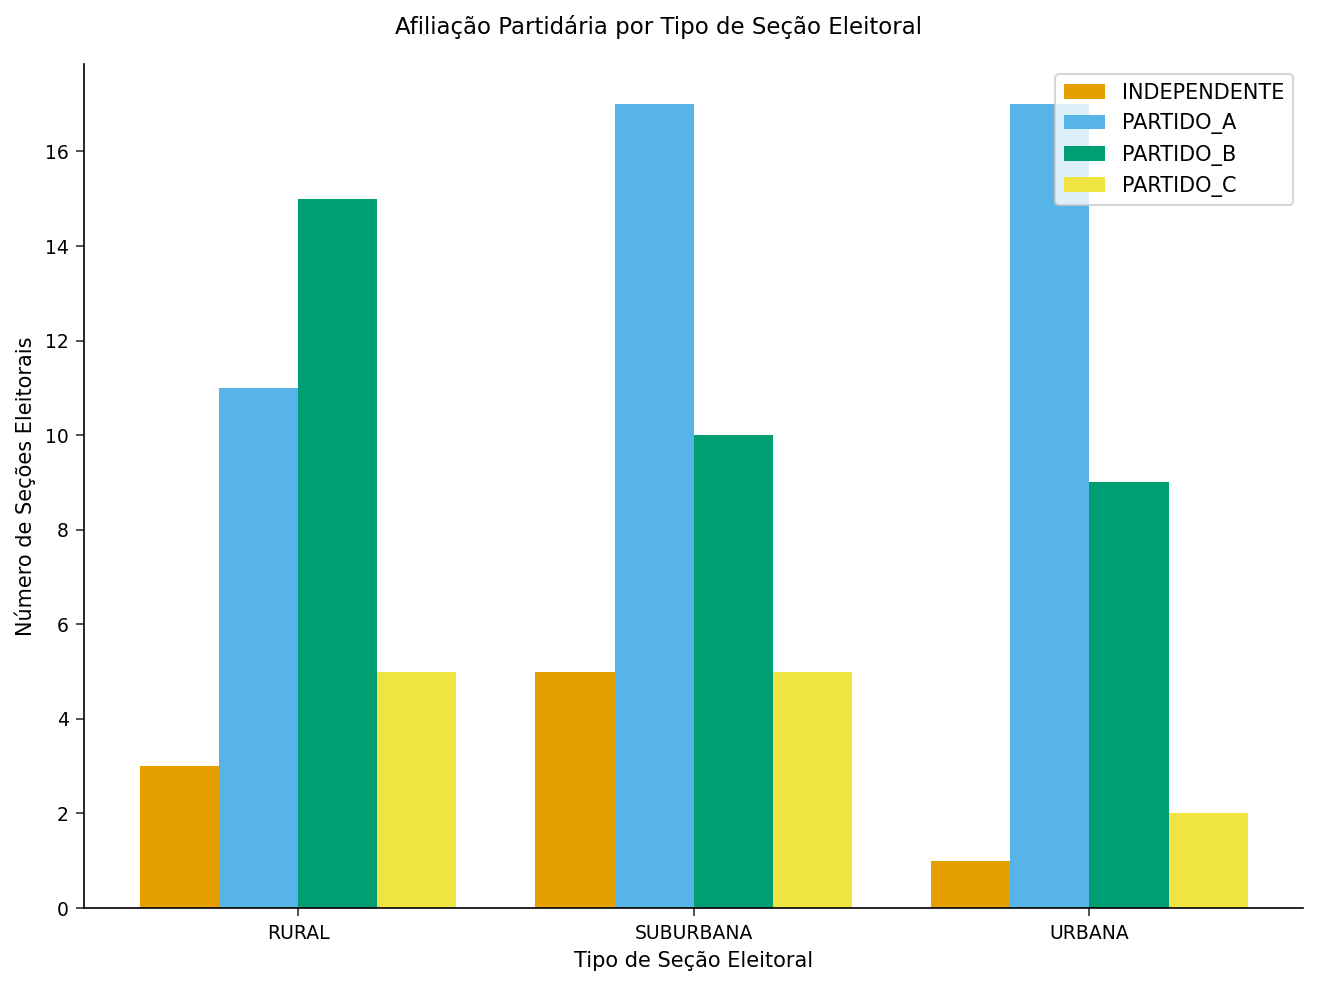

In [3]:
/* --------------------------------------------------------
   Afiliação partidária por tipo de seção (contagem de seções)
   -------------------------------------------------------- */
PROCEDIMENTO SGPLOT DADOS=work.precinct_votes;
    VBAR precinct_type / GROUP=party GROUPDISPLAY=CLUSTER
        STAT=FREQUÊNCIAS;
    XAXIS RÓTULO='Tipo de Seção Eleitoral';
    YAXIS RÓTULO='Número de Seções Eleitorais';
    TÍTULO 'Afiliação Partidária por Tipo de Seção Eleitoral';
EXECUTAR;

---

                     Tipo de Seção Eleitoral por Partido: Tabulação Cruzada com Contagens Esperadas                     

                                                   The FREQ Procedure

Table of Tipo de Seção Eleitoral by Partido

Tipo de Seção Eleitoral   |INDEPENDENTE |   PARTIDO_A |   PARTIDO_B |   PARTIDO_C |        Total
--------------------------+-------------+-------------+-------------+-------------+-------------
RURAL                     |           3 |          11 |          15 |           5 |           34
                          |        3.00 |       11.00 |       15.00 |        5.00 |        34.00
                          |        3.06 |       15.30 |       11.56 |        4.08 |             
                          |        8.82 |       32.35 |       44.12 |       14.71 |       100.00
                          |       33.33 |       24.44 |       44.12 |       41.67 |        34.00
--------------------------+-------------+-------------+-------------+-------------+


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.


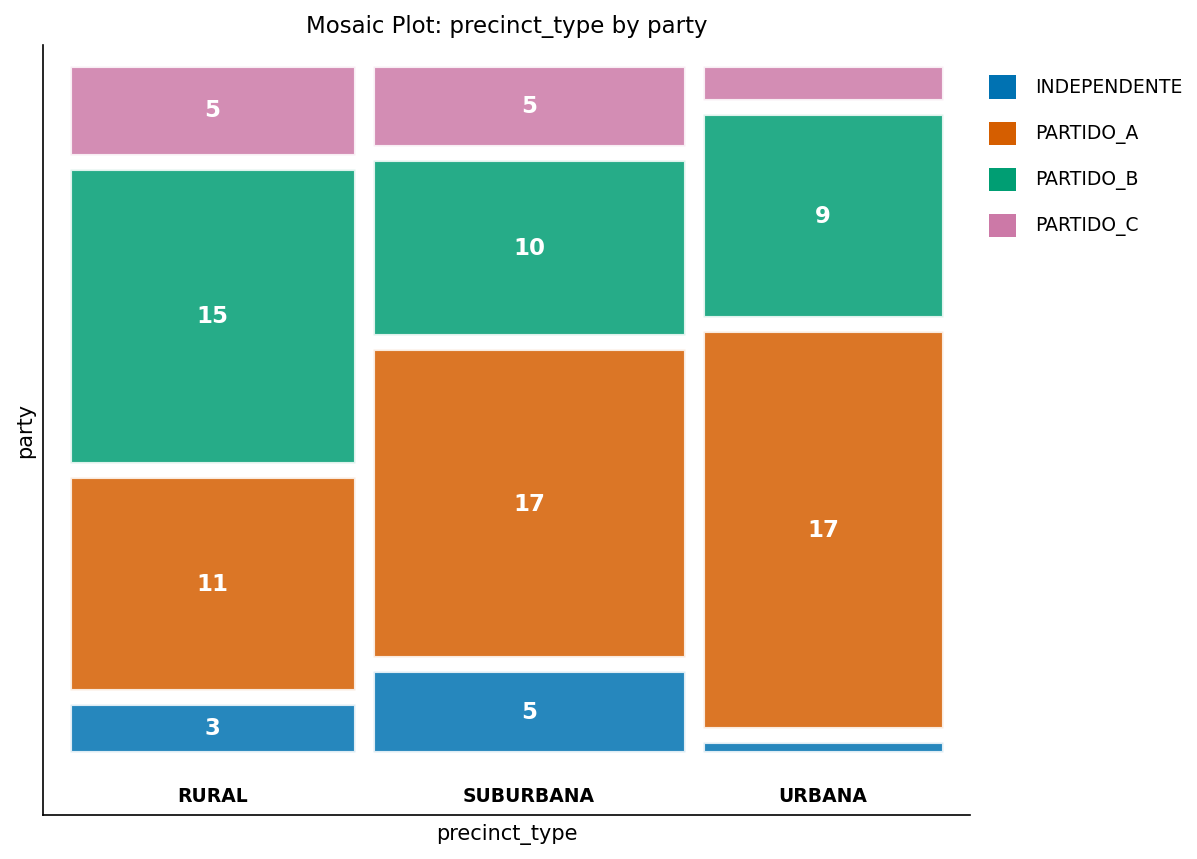

In [4]:
/* --------------------------------------------------------
   Tabulação cruzada tipo de seção x partido.
   Solicita contagens ESPERADAS para que as células esparsas
   fiquem visíveis, mais o teste qui-quadrado assintótico de
   Pearson de associação geral. Observe as contagens esperadas
   pequenas nas colunas INDEPENDENTE e PARTIDO_C -- o indício
   de que um teste de tendência ordenado e exato é a
   ferramenta inferencial melhor.
   -------------------------------------------------------- */
PROCEDIMENTO FREQUÊNCIAS DADOS=work.precinct_votes;
    TABLES precinct_type * party / chisq expected;
    RÓTULO precinct_type = 'Tipo de Seção Eleitoral'
          party = 'Partido';
    TÍTULO 'Tipo de Seção Eleitoral por Partido: Tabulação Cruzada com Contagens Esperadas';
EXECUTAR;

         Teste de Tendência de Cochran-Armitage: Apoio ao Partido A ao Longo do Gradiente de Seções Eleitorais          

                                                   The FREQ Procedure

Table of Ordem do Tipo de Seção by Indicador Partido A

Ordem do Tipo de Seção   |         0 |         1 |      Total
-------------------------+-----------+-----------+-----------
1                        |        12 |        17 |         29
                         |     12.00 |     17.00 |      29.00
                         |     41.38 |     58.62 |     100.00
                         |     21.82 |     37.78 |      29.00
-------------------------+-----------+-----------+-----------
2                        |        20 |        17 |         37
                         |     20.00 |     17.00 |      37.00
                         |     54.05 |     45.95 |     100.00
                         |     36.36 |     37.78 |      37.00
-------------------------+-----------+-----------+-----------
3      


NOTE: DATA work.precinct_ordinal


NOTE: Read 100 rows from work.precinct_votes.
NOTE: Wrote work.precinct_ordinal (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_type_order_party_a_flag.spec.json
NOTE: PROC FREQ statement used.


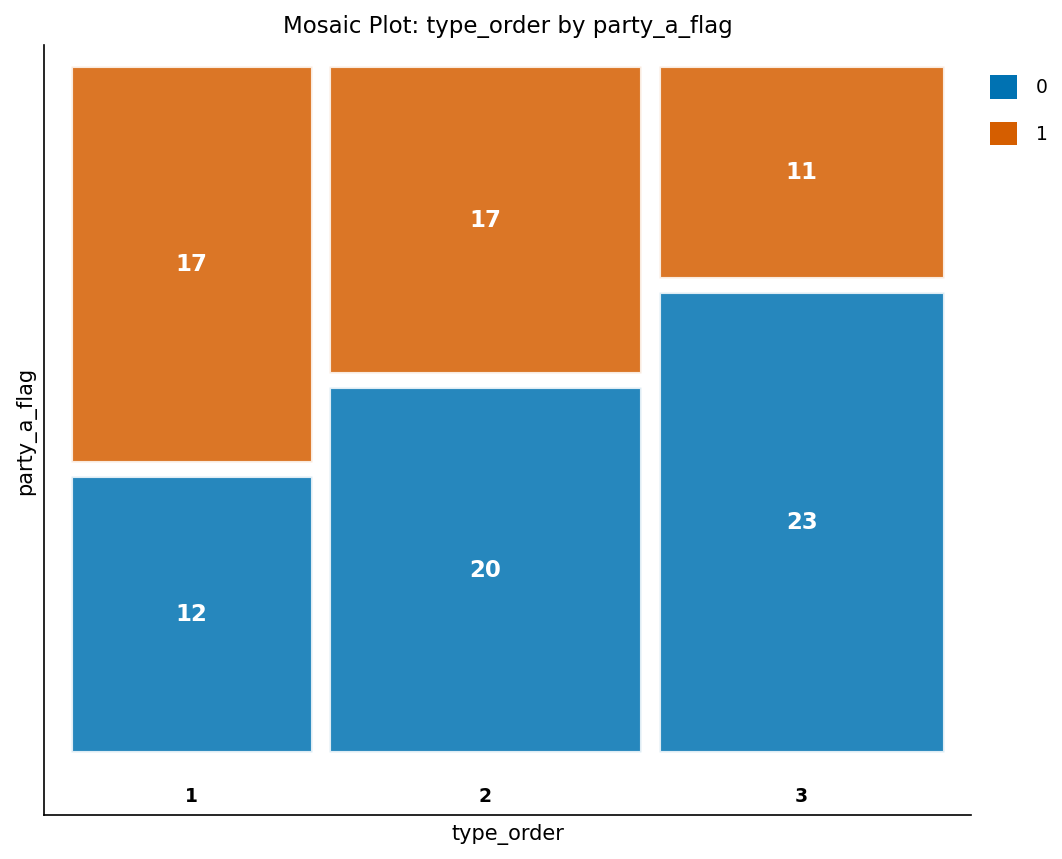

In [5]:
/* --------------------------------------------------------
   Teste de tendência de Cochran-Armitage. Recodifica o tipo
   de seção para uma pontuação ordinal (1=Urbana, 2=Suburbana,
   3=Rural) e testa se o apoio ao Partido A mostra uma
   tendência monotônica ao longo do gradiente. EXACT TREND
   solicita o valor-p exato, apropriado dadas as contagens
   pequenas de células.
   -------------------------------------------------------- */
DADOS work.precinct_ordinal;
    DEFINIR work.precinct_votes;
    /* Codificação ordinal: 1=Urbana, 2=Suburbana, 3=Rural */
    SE precinct_type = 'URBANA' ENTÃO type_order = 1;
    SENÃO SE precinct_type = 'SUBURBANA' ENTÃO type_order = 2;
    SENÃO type_order = 3;
    /* Resultado binário: Partido A vs. todas as outras afiliações */
    party_a_flag = (party = 'PARTIDO_A');
EXECUTAR;

PROCEDIMENTO FREQUÊNCIAS DADOS=work.precinct_ordinal;
    TABLES type_order * party_a_flag / chisq trend;
    EXACT trend;
    RÓTULO type_order = 'Ordem do Tipo de Seção'
          party_a_flag = 'Indicador Partido A';
    TÍTULO 'Teste de Tendência de Cochran-Armitage: Apoio ao Partido A ao Longo do Gradiente de Seções Eleitorais';
EXECUTAR;

                                  Distribuição do Tipo de Seção Eleitoral por Condado                                   

                                                   The FREQ Procedure

Table of Condado by Tipo de Seção Eleitoral

Condado   |     RURAL | SUBURBANA |    URBANA |      Total
----------+-----------+-----------+-----------+-----------
ADAMS     |         5 |        10 |         4 |         19
          |      5.00 |     10.00 |      4.00 |      19.00
          |     26.32 |     52.63 |     21.05 |     100.00
          |     14.71 |     27.03 |     13.79 |      19.00
----------+-----------+-----------+-----------+-----------
HAMILTON  |         7 |         7 |         7 |         21
          |      7.00 |      7.00 |      7.00 |      21.00
          |     33.33 |     33.33 |     33.33 |     100.00
          |     20.59 |     18.92 |     24.14 |      21.00
----------+-----------+-----------+-----------+-----------
JEFFERSON |         4 |         7 |         7 |       


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_county_name_precinct_type.spec.json
NOTE: PROC FREQ statement used.


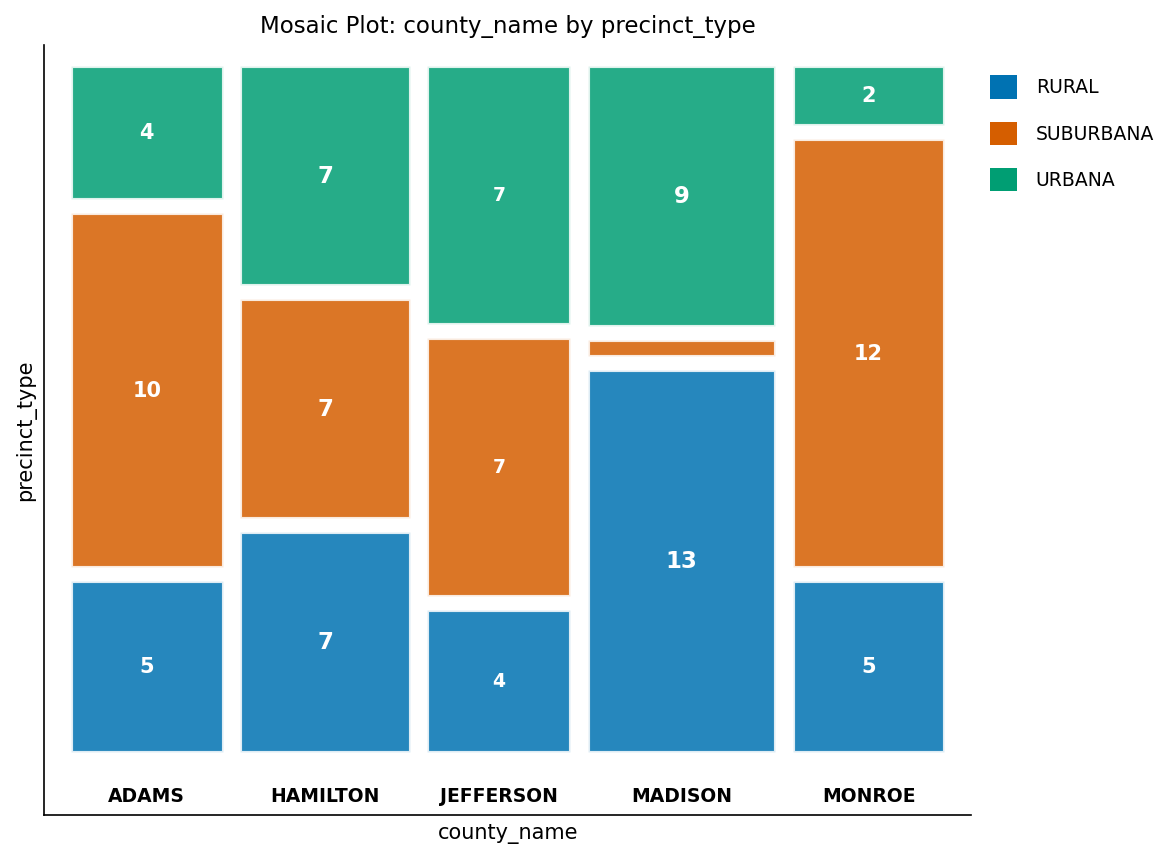

In [6]:
/* --------------------------------------------------------
   Visão a nível de condado: como a mistura urbana/suburbana/
   rural varia entre os cinco condados. Isso contextualiza o
   resultado da tendência -- o gradiente de seções está
   presente em todo condado, mas sua composição difere.
   -------------------------------------------------------- */
PROCEDIMENTO FREQUÊNCIAS DADOS=work.precinct_votes;
    TABLES county_name * precinct_type / nocum;
    RÓTULO county_name = 'Condado'
          precinct_type = 'Tipo de Seção Eleitoral';
    TÍTULO 'Distribuição do Tipo de Seção Eleitoral por Condado';
EXECUTAR;

---

### Interpretação

Nas 100 seções eleitorais, o Partido A detém a pluralidade geral (45
seções), seguido pelo Partido B (34), Partido C (12) e Independentes (9).
A tabulação cruzada mostra que a participação do Partido A segue um
gradiente claro de urbano para rural: ele representa 58.6% das seções
urbanas, 46.0% das seções suburbanas e 32.4% das seções rurais, enquanto
o Partido B se move na direção oposta, subindo de 31.0% urbano para
44.1% rural.

O teste qui-quadrado de Pearson geral (omnibus) de associação geral
**não** é estatisticamente significativo (qui-quadrado = 6.78, 6 gl,
p = 0.3418; V de Cramer = 0.18). Esse resultado também é frágil: a
exibição de contagens esperadas revela várias células abaixo de cinco —
por exemplo, a coluna Independente tem contagens esperadas de 3.06, 3.33
e 2.61, e os Independentes urbanos somam apenas uma seção — portanto a
aproximação qui-quadrado de grande amostra é pouco confiável aqui.

O teste de tendência de Cochran-Armitage refina a pergunta usando a
pontuação ordinal urbano-suburbano-rural. Ele detecta o declínio
monotônico no apoio ao Partido A que o teste omnibus não capta:
qui-quadrado de tendência = 4.38 com Pr > ChiSq assintótico = 0.0363 e
um **Pr exato >= |Z| = 0.0431**, significativo no nível de 0.05. Este é
o ganho analítico — um teste focado, exato, de um grau de liberdade
recupera um sinal direcional real que o teste de associação genérico de
6 graus de liberdade, enfraquecido por células esparsas, não detecta.

A visão a nível de condado confirma que a divisão urbano/suburbano/rural
está presente em todos os cinco condados, embora a mistura difira:
Madison é o mais rural (13 de 23 seções rurais) enquanto Monroe é o mais
suburbano (12 de 19). Para a avaliação de impacto de redistritamento, a
conclusão é que mudanças de limites que deslocam seções ao longo do eixo
urbano-rural alterariam mensuravelmente a composição partidária, e que
essa tendência geográfica é melhor evidenciada pelo teste de tendência
exato do que pelo qui-quadrado omnibus.

---

                                  Distribuição do Tipo de Seção Eleitoral por Condado                                   

                                                   The FREQ Procedure

Table of Tipo de Seção Eleitoral by Partido

Tipo de Seção Eleitoral   |INDEPENDENTE |   PARTIDO_A |   PARTIDO_B |   PARTIDO_C |        Total
--------------------------+-------------+-------------+-------------+-------------+-------------
RURAL                     |           3 |          11 |          15 |           5 |           34
                          |        3.00 |       11.00 |       15.00 |        5.00 |        34.00
                          |        8.82 |       32.35 |       44.12 |       14.71 |       100.00
                          |       33.33 |       24.44 |       44.12 |       41.67 |        34.00
--------------------------+-------------+-------------+-------------+-------------+-------------
SUBURBANA                 |           5 |          17 |          10 |           5 |


NOTE: PROC FREQ
NOTE: Output dataset work.voting_pattern_summary has 12 observations and 4 variables.
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.voting_pattern_summary outfile=precinct_voting_patterns.csv

NOTE: Exported 12 rows to precinct_voting_patterns.csv.


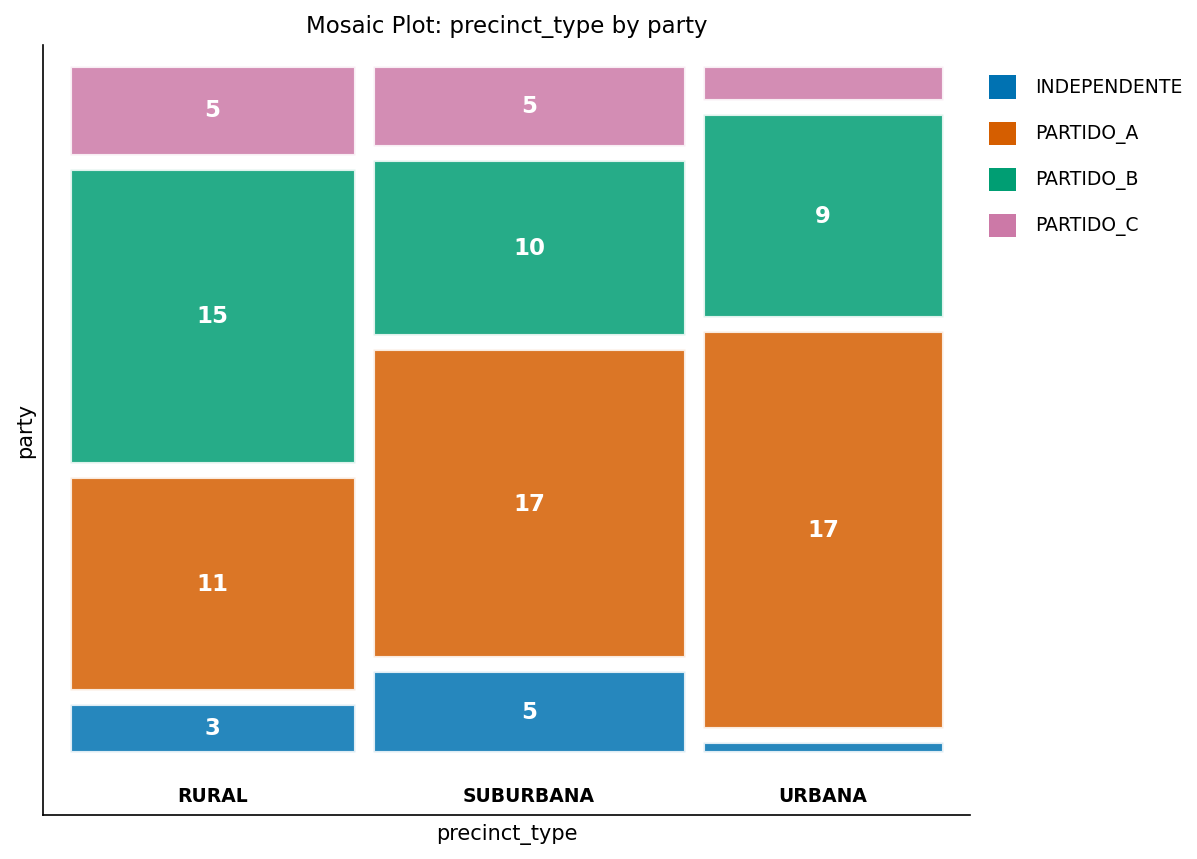

In [7]:
/* --------------------------------------------------------
   Exportar o resumo tipo de seção x partido para avaliação de
   impacto de redistritamento downstream.
   -------------------------------------------------------- */
PROCEDIMENTO FREQUÊNCIAS DADOS=work.precinct_votes;
    TABLES precinct_type * party / out=work.voting_pattern_summary nocum;
    RÓTULO precinct_type = 'Tipo de Seção Eleitoral'
          party = 'Partido';
EXECUTAR;

PROCEDIMENTO EXPORT DADOS=work.voting_pattern_summary
    OUTFILE='precinct_voting_patterns.csv'
    DBMS=csv REPLACE;
EXECUTAR;

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desenvolvido por <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>